In [1]:
import pandas as pd
from glob import glob
from braceexpand import braceexpand
import numpy as np
import matplotlib.pyplot as plt
import pickle
import xarray as xr
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'POSTPROCESSING')))
from ETC_tools import open_files, calculate_ranking
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as ticker

## Ici, on trace les POE des EETCs qui ne sont pas forçement des compounds

C'est à dire que l'on ne fait pas de ranking avec le produit de deux métriques en amont, on inclue dans le plot de chacune des métriques les ETCs qui sont des extrêmes dans une variable, mais pas forcément dans l'autre. Ainsi, il y'a davantage d'ETCs qu'il n'y a de points dans le scatter plot de la sélection des EETCs. En réalité, il y'apeu de différence, seulement pour les EETCs les plus faibles, mais ceux qui sont un peu plus extrêmes sont tous des compounds.

In [2]:
simulations = ['ERA5', 'UBB', 'UBD', 'UBE', 'UBF']
quantile = 0.99
metric = 'diff' #How the metrics have been calculated (diff or ratio)
if metric == 'ratio':
    thr_value = 1.
elif metric == 'diff':
    thr_value = 0.

In [3]:
EETC_dict = {}
df = {}

for sim in simulations:
    df_sim, EETC_dict_sim = open_files(sim, metric=metric, wetdays=False, future=False, original_selection=False, period_filtering=True) #pour l'instant on met future car diff avec les historiques a future_percentile dans add_file

    EETC_dict[sim] = EETC_dict_sim
    df[sim] = df_sim

Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_ERA5_Quebec_1000hPa_1979-2023_compound_8hrs_quantile_SSI_diff.pkl with True period filtering
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBB_Quebec_1000hPa_1979-2023_compound_8hrs_quantile_SSI_diff.pkl with True period filtering
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBD_Quebec_1000hPa_1979-2014_compound_8hrs_quantile_SSI_diff.pkl with True period filtering
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBE_Quebec_1000hPa_1979-2014_compound_8hrs_quantile_SSI_diff.pkl with True period filtering
Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_UBF_Quebec_1000hPa_1979-2014_compound_8hrs_quantile_SSI_diff.pkl with True period filtering


### We associate the date at which the pressure was minimum for each extreme ETCs of the dict, to later do a seasonal discrimation

In [4]:
metrics = ['cum_precip', 'cum_avg_precip', 'cum_wind', 'cum_avg_wind']
for sim in simulations:
    for storm in EETC_dict[sim]:
        if (
            any(EETC_dict[sim][storm][m].sel(quantile=quantile).values > thr_value for m in metrics)
            or (EETC_dict[sim][storm]['SSI'].sel(quantile=quantile).values != 0)
        ):
            storm_group = df[sim].groupby('storm').get_group(storm)
            min_pressure_row = storm_group.loc[storm_group['pressure'].idxmin()]
            EETC_dict[sim][storm]['min_pressure_date'] = min_pressure_row['date']

In [5]:
plot_params = [
    {
        "var": "cum_precip",
        # "label": '$ETC_{PR,cum}|_{QC}$ [mm]',
        "label": '$ETC_{PR,cum}|_{QC}$',
        "unit": '[mm]',
        "ax_index": (0, 0)
    },
    {
        "var": "cum_avg_precip",
        # "label": '$\overline{{ETC}_{PR}|_{QC}}$ [mm.h$^{{-1}}$]',
        "label": '$\overline{{ETC}_{PR}|_{QC}}$',
        "unit": '[mm.h$^{{-1}}$]',
        "ax_index": (0, 1)
    },
    # {
    #     "var": "SSI",
    #     "label": '$SSI$',
    #     "ax_index": (1, 0)
    # },
    {
        "var": "cum_wind",
        # "label": '$ETC_{WS,cum}|_{QC}$ [km.h$^{{-1}}$]',
        "label": '$ETC_{WS,cum}|_{QC}$',
        "unit": '[km.h$^{{-1}}$]',
        "ax_index": (1, 0)
    },
    {
        "var": "cum_avg_wind",
        # "label": '$\overline{{ETC}_{WS}|_{QC}}$ [km.h$^{{-1}}$]',
        "label": '$\overline{{ETC}_{WS}|_{QC}}$',
        "unit": '[km.h$^{{-1}}$]',
        "ax_index": (1, 1)
    }
]

sim_label = {
    'ERA5': r'ERA5',
    'UBB': r'CRCM6$_{\mathrm{ERA5}}$',
    'UBD': r'CRCM6$_{\mathrm{EC\text{-}Earth3\text{-}Veg}}$',
    'UBG': r'CRCM6$_{\mathrm{EC\text{-}Earth3\text{-}Veg}}$',
    'UBE': r'CRCM6$_{\mathrm{MPI\text{-}ESM1\text{-}2\text{-}HR}}$',
    'UBH': r'CRCM6$_{\mathrm{MPI\text{-}ESM1\text{-}2\text{-}HR}}$',
    'UBF': r'CRCM6$_{\mathrm{MIROC6}}$',
    'UBI': r'CRCM6$_{\mathrm{MIROC6}}$' 
}

def clean_log_format(x, pos):
    if x >= 1 and x == int(x):
        return str(int(x))  # Affiche 1, 10, 100
    elif x < 1:
        return f"{x:.1g}"   # Par exemple : 0.1
    else:
        return str(x)

In [ ]:
# def count_by_season(keys, EETC_dict):
#     counts = {"DJF": 0, "MAM": 0, "JJA": 0, "SON": 0}
#     for k in keys:
#         date = EETC_dict[k]["min_pressure_date"]
#         m = date.month
#         if   m in [12, 1, 2]: counts["DJF"] += 1
#         elif m in [3, 4, 5]:  counts["MAM"] += 1
#         elif m in [6, 7, 8]:  counts["JJA"] += 1
#         elif m in [9, 10, 11]:counts["SON"] += 1
#     return counts
#     season_counts = {sim: {} for sim in simulations}

# for sim in simulations:
#     for params in plot_params:
#         var = params["var"]
#         counts = count_by_season(keys, EETC_dict[sim])
#         season_counts[sim][var] = counts
#         print(f"{sim} - {var}: {counts}")

# # season_counts now holds counts per simulation and per metric, e.g. season_counts['ERA5']['cum_precip']

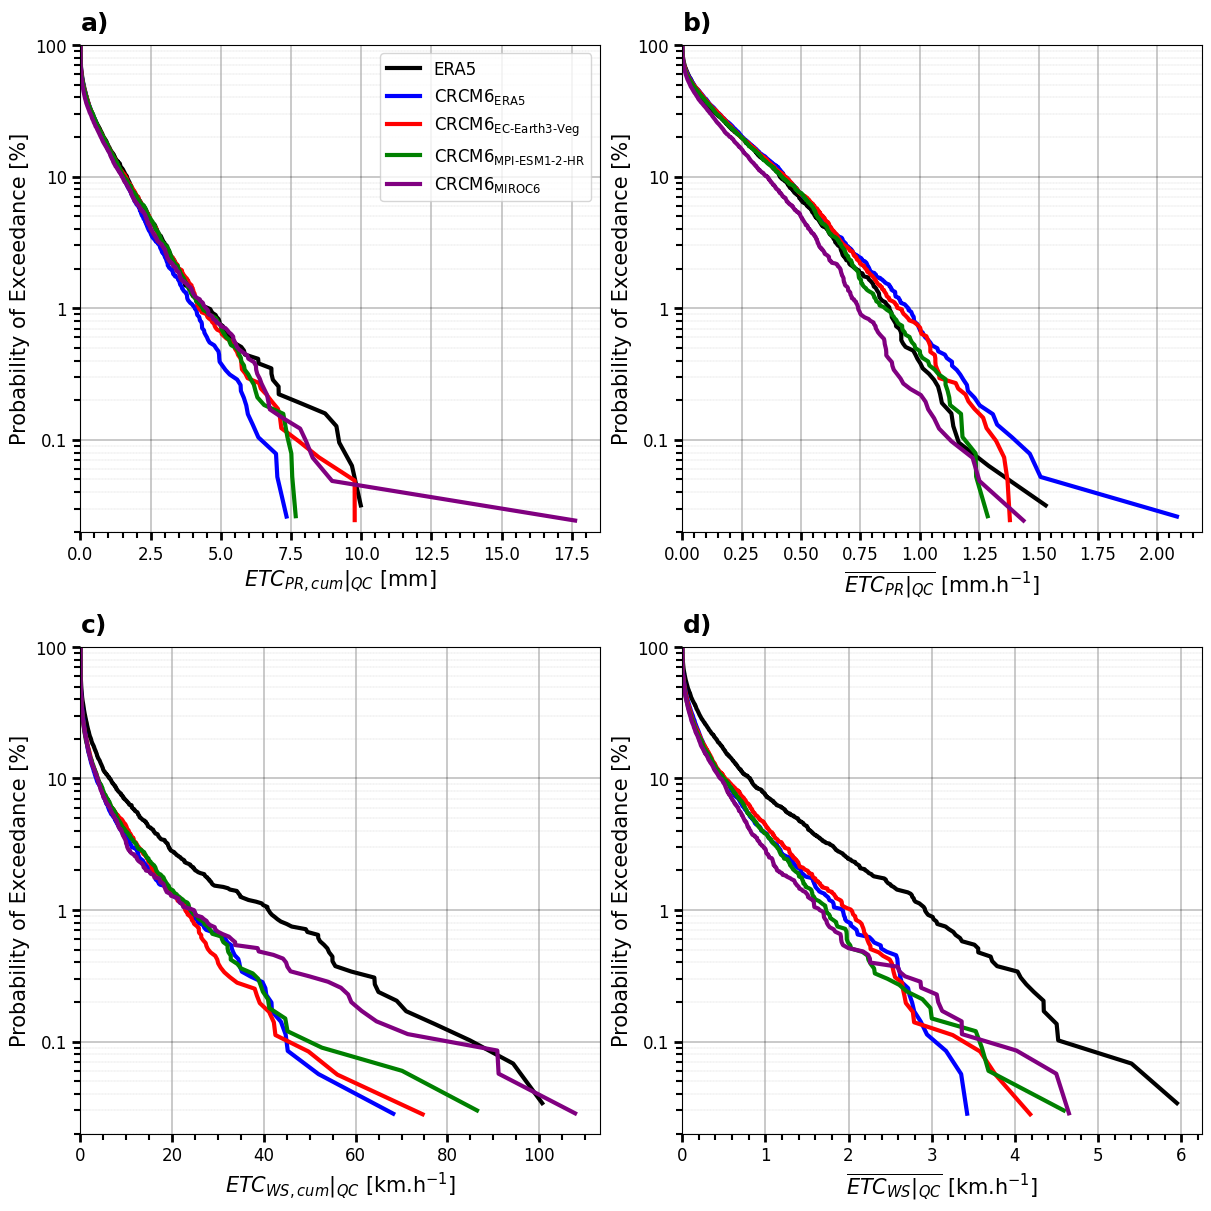

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

# colors = ['k', '#0072B2', '#E69F00', '#009E73', '#D55E00']
colors = ['k', 'blue', 'red', 'green', 'purple']

for i, params in enumerate(plot_params):
    ax = axes[params["ax_index"]]
    
    for isim, sim in enumerate(simulations): 
        EETCs_var = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
        ]
            
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability
        
        ax.plot(sorted_vals, prob_exceedance * 100, color=colors[isim % len(colors)], linestyle='-', label=sim_label[sim], linewidth=3)
        
    letter = f"$\\mathbf{{{chr(97+i)})}}$"
    ax.text(0, 1.02, letter, transform=ax.transAxes, fontsize=18, ha='left', va='bottom')
    ax.set_xlim(0, None)
    # ax.set_xticks([1, 2, 5, 10])
    # ax.set_ylim(-1.3, 2)  # Set y-axis limits to stop at 10^0
    ax.set_ylim(0.02, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"] + ' ' + params["unit"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    if params["ax_index"] == (0, 0): ax.legend(fontsize=12, loc='upper right')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"Probability of Exceedance of the strongest ETCs over Québec from 1980 to 2014 or 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

## Seasonal PoE

### ERA5

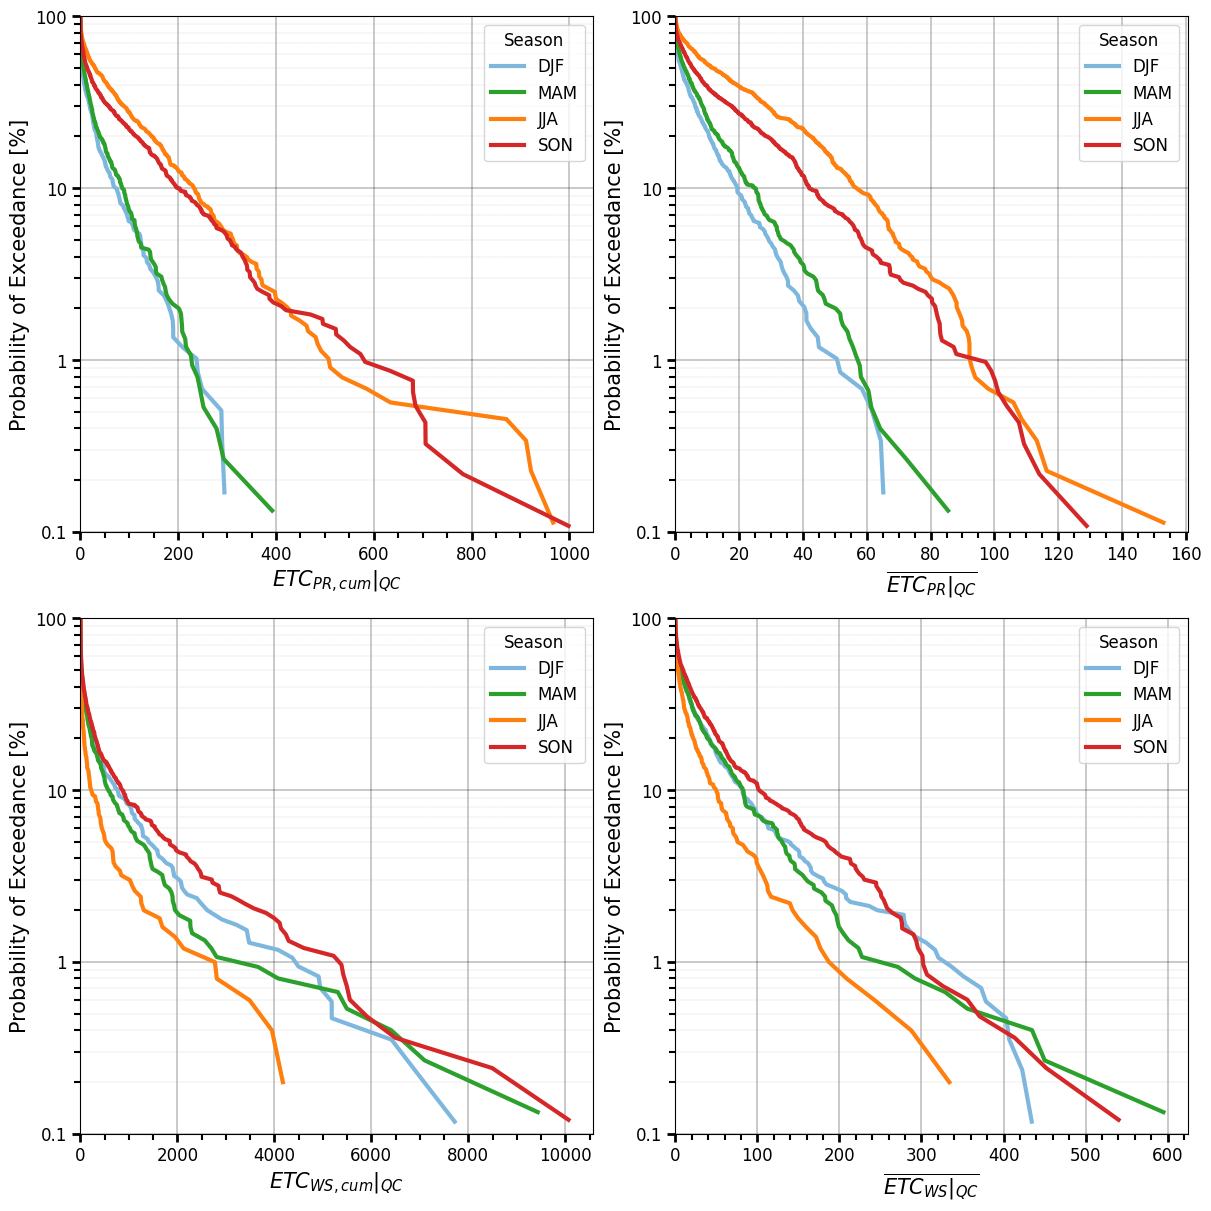

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[0]
    isim = 0
    
    for season, months in seasons.items():  
        EETCs_var = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ] 
            
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals * 100, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)
    
    ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right', title='Season', title_fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1980 to 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

### UBB

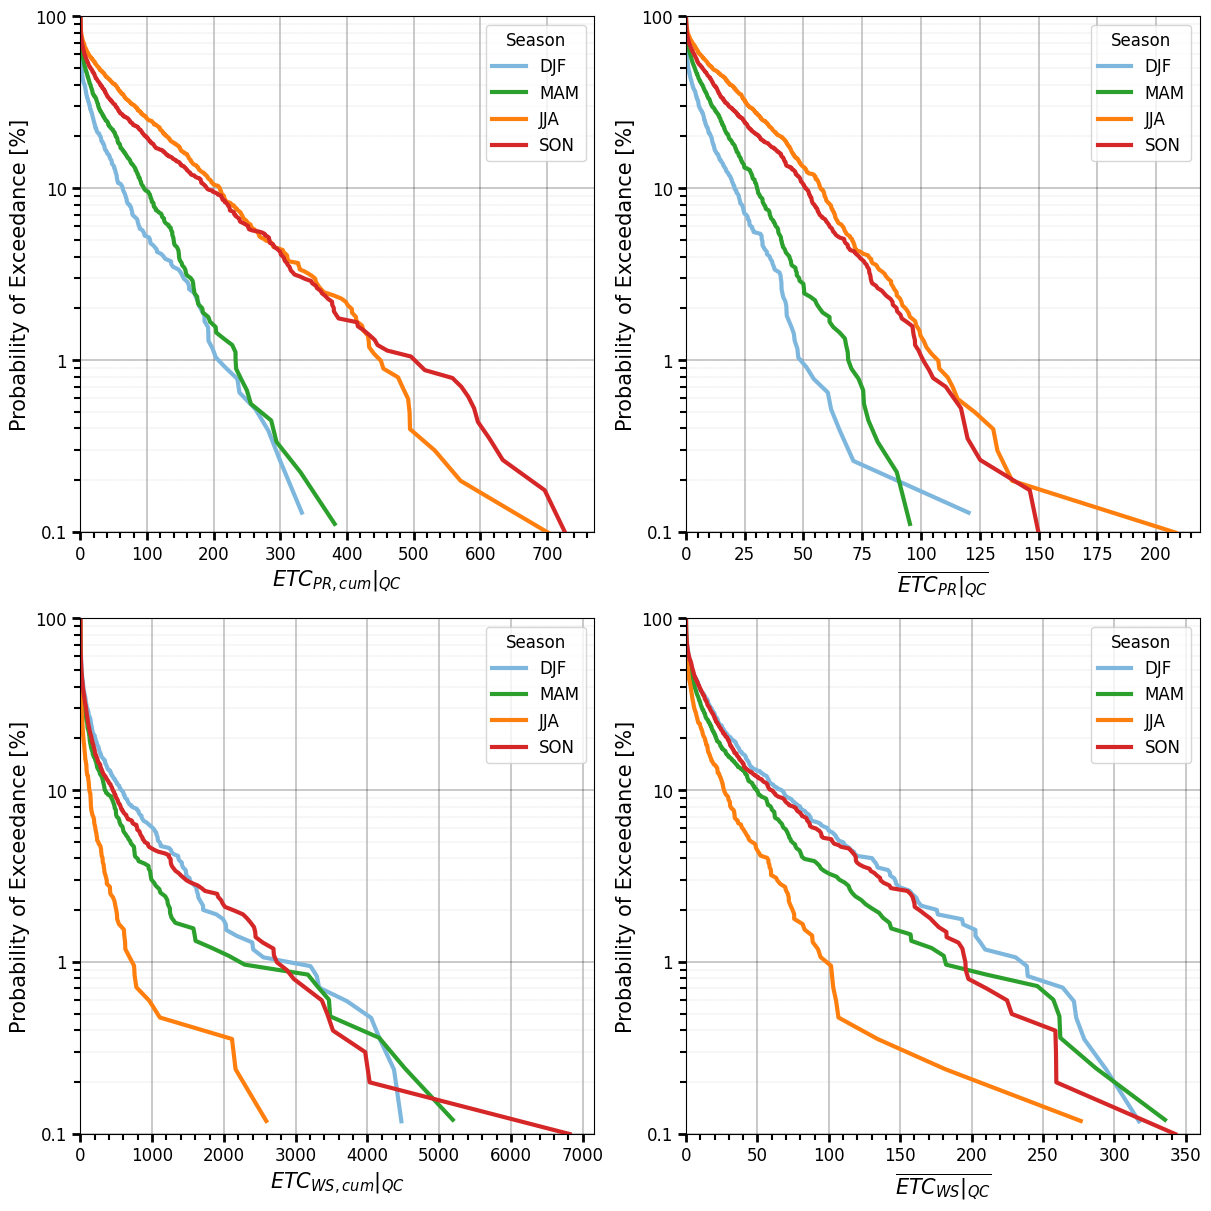

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[1]
    isim = 1
    
    for season, months in seasons.items(): 
        EETCs_var = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ] 
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals * 100, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)
        
    ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right', title='Season', title_fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1980 to 2023 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

### UBD

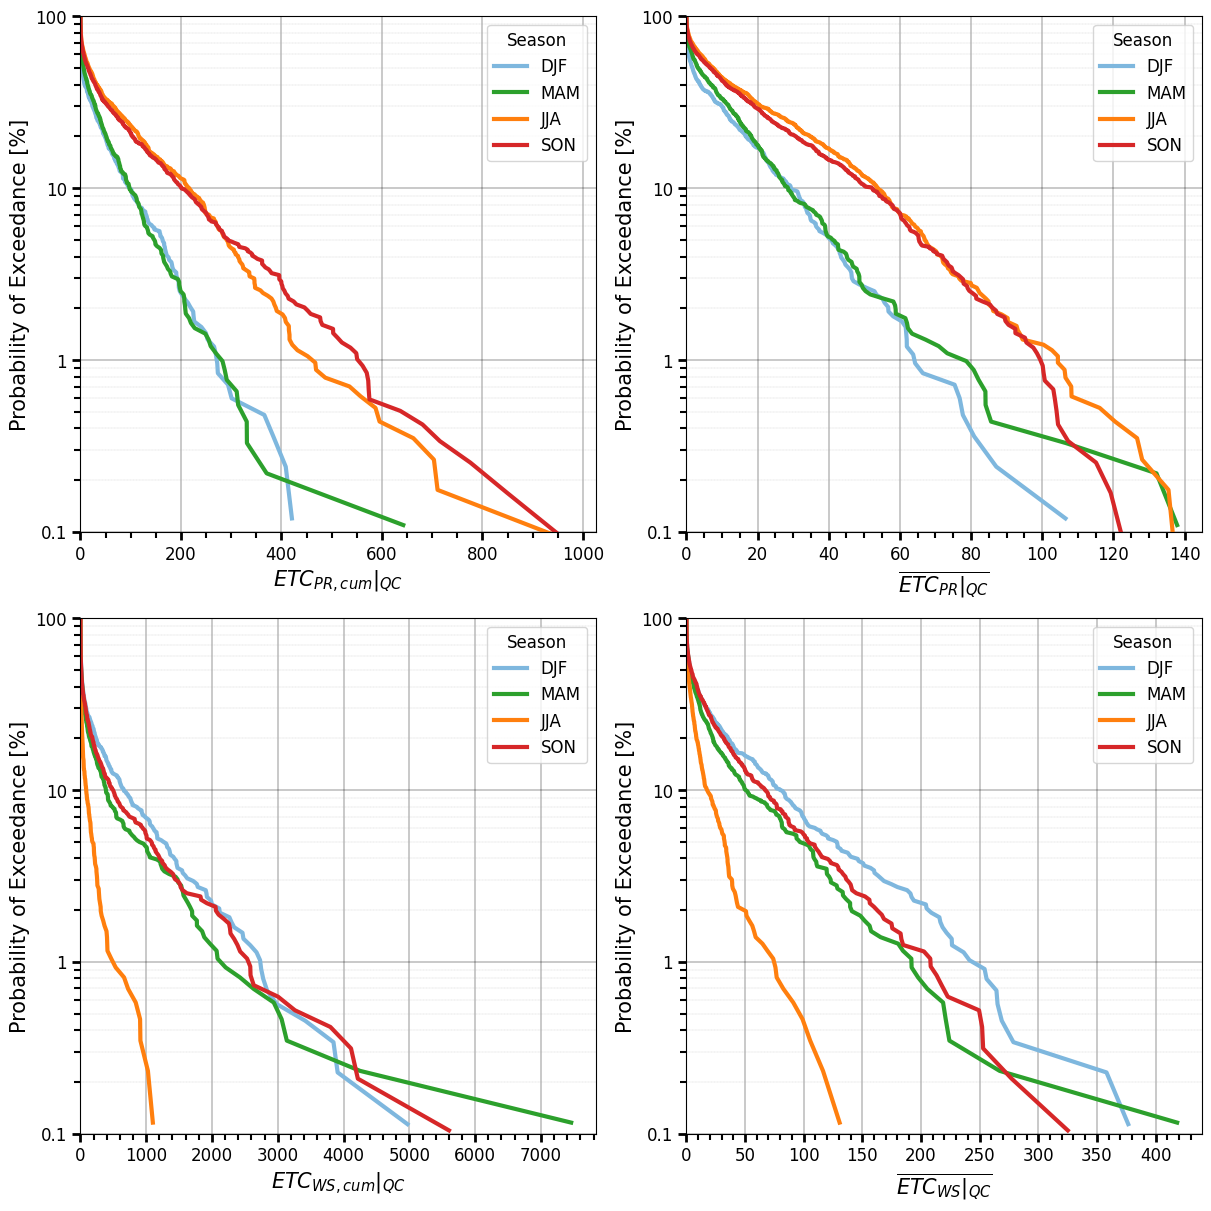

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[2]
    isim = 2
    
    for season, months in seasons.items():   
        EETCs_var = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ]  
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals * 100, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)

    ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right', title='Season', title_fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1980 to 2014 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

### UBE

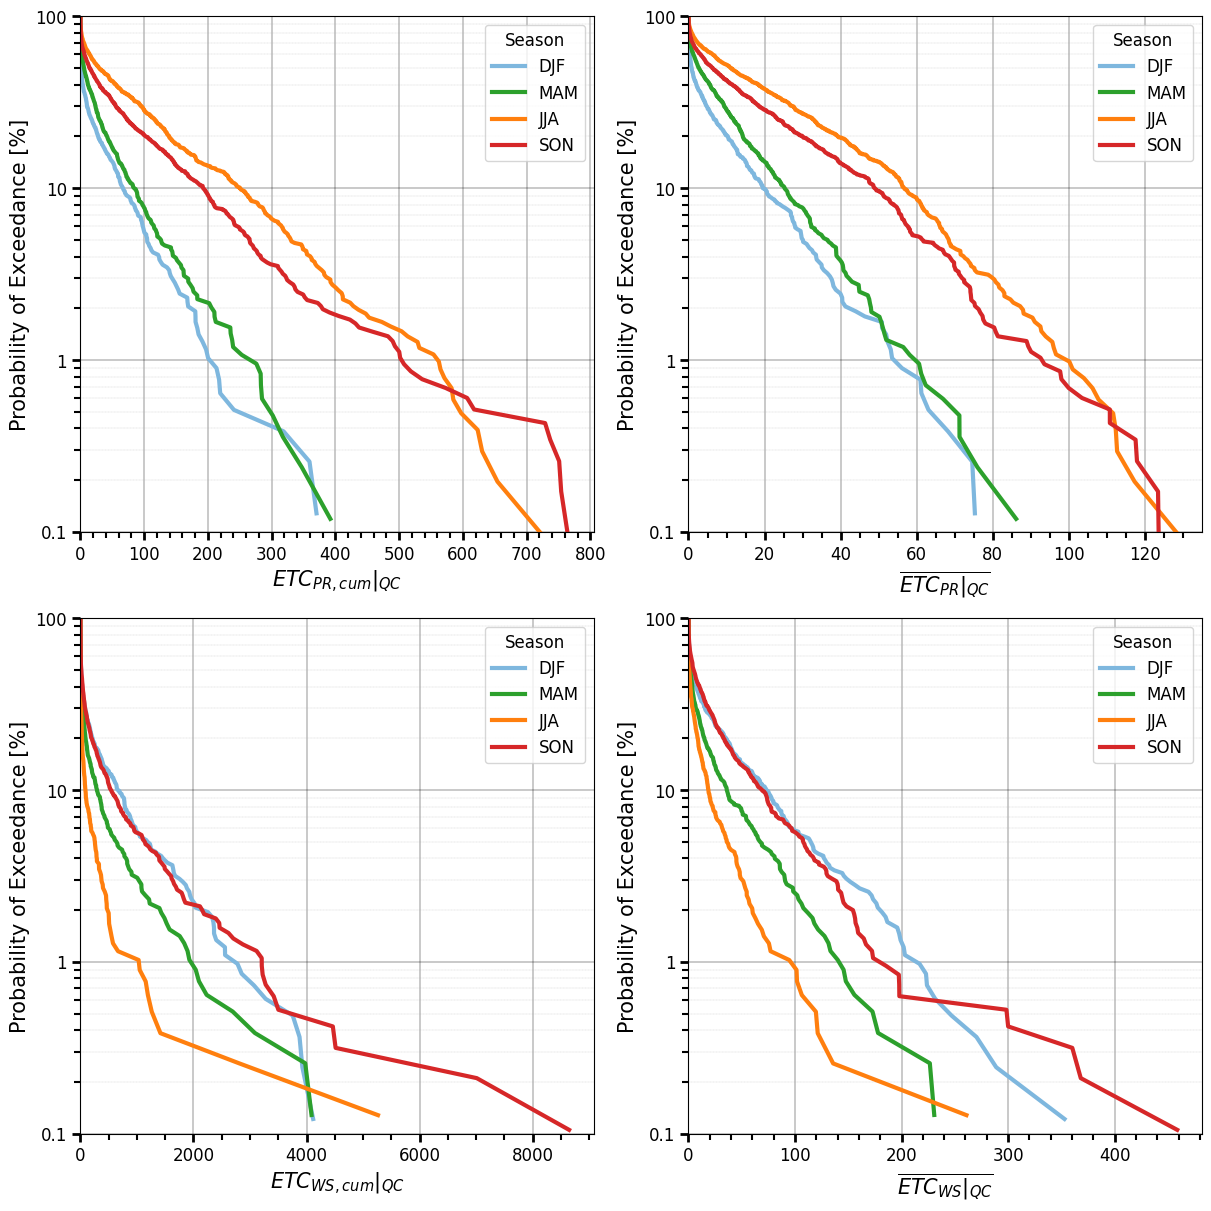

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[3]
    isim = 3
    
    for season, months in seasons.items():
        EETCs_var = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ] 
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals * 100, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)

    ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right', title='Season', title_fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1980 to 2014 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)

### UBF

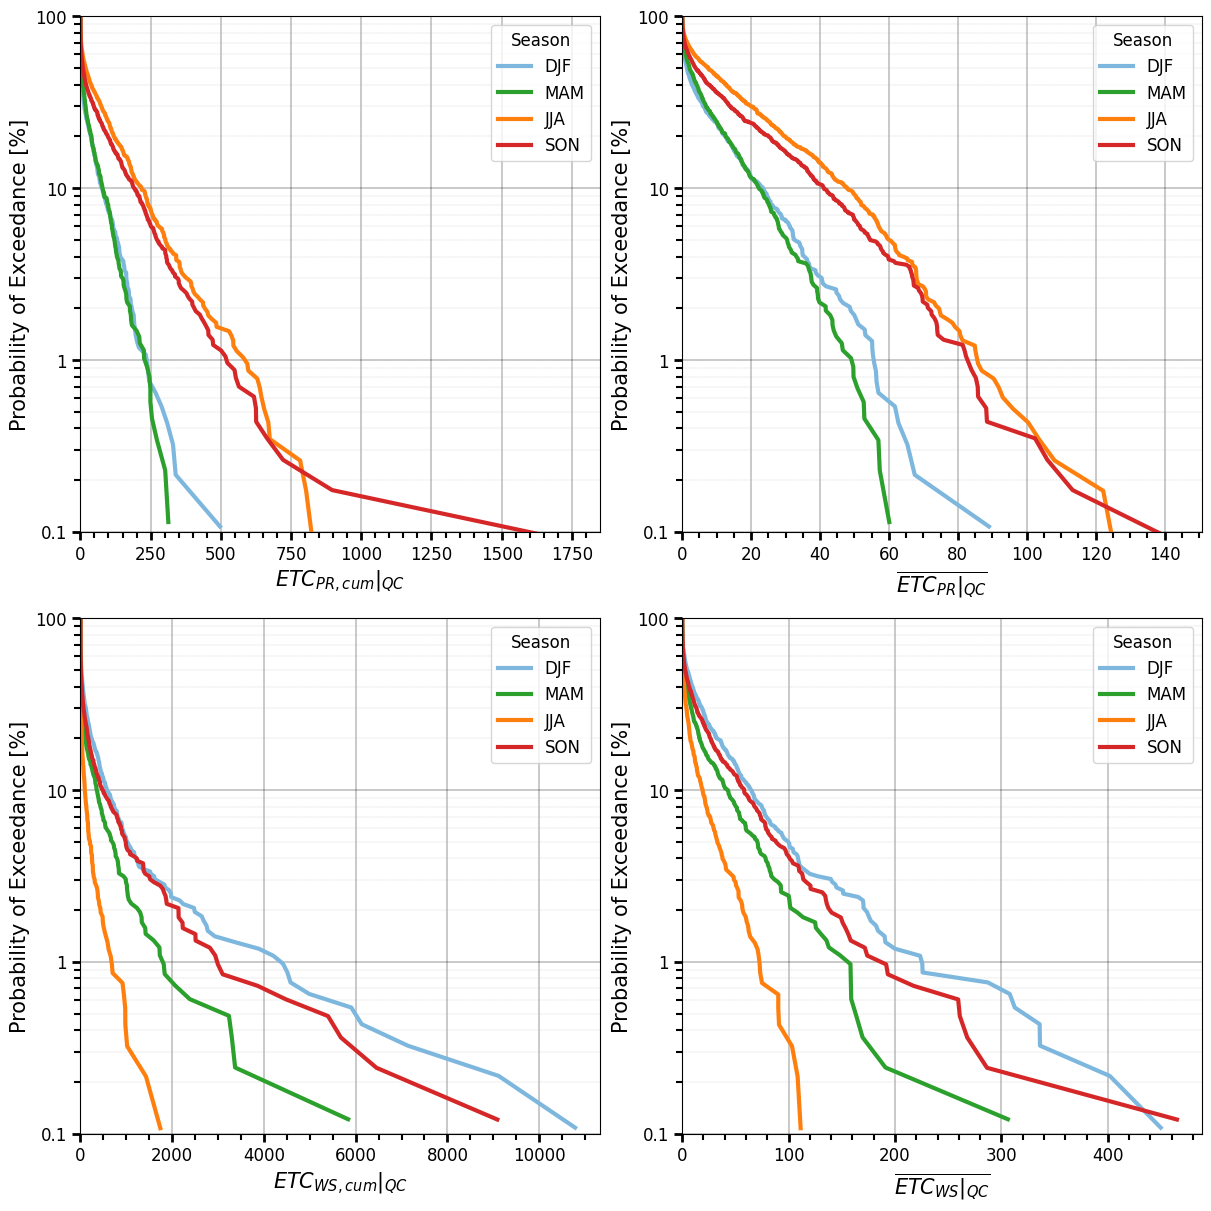

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

seasons = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
season_color = {'DJF': '#7eb7de', 'MAM': '#2ca02c', 'JJA': '#ff7f0e', 'SON': '#d62728'}

for params in plot_params:
    ax = axes[params["ax_index"]]
    
    sim = simulations[4]
    isim = 4
    
    for season, months in seasons.items():  
        EETCs_var = [
            EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values
            for k in EETC_dict[sim]
            if (
                EETC_dict[sim][k][params["var"]].sel(quantile=quantile).values > thr_value
                and pd.to_datetime(EETC_dict[sim][k]['min_pressure_date']).month in months
            )
        ] 
        
        # Sort values for probability of exceedance
        sorted_vals = np.sort(EETCs_var)[::-1]  # Sort in descending order
        prob_exceedance = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)  # Calculate exceedance probability

        ax.plot(sorted_vals * 100, prob_exceedance * 100, color=season_color[season], label=f"{season}", linewidth=3)

    ax.set_xlim(0, None)
    ax.set_ylim(0.1, 100)  # Set y-axis limits to stop at 10^0
    ax.set_yscale('log')  # Set y-axis to logarithmic scale
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(clean_log_format))
    ax.set_xlabel(params["label"], fontsize=15)
    ax.set_ylabel("Probability of Exceedance [%]", fontsize=15)
    # ax.set_title(params["label"], fontsize=15)
    ax.legend(fontsize=12, loc='upper right', title='Season', title_fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=10, width=1.5, length=4)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.minorticks_on()
    ax.grid(True, which='major', axis='both', linestyle='-', linewidth=0.3, c='black')
    ax.grid(True, which='minor', axis='y', linestyle='--', linewidth=0.2)

# fig.suptitle(f"{sim} Probability of Exceedance of the strongest ETCs over Québec from 1980 to 2014 — ${quantile*100:.1f}^{{th}}$ percentile", fontsize=16)